Final demo with yolo26n_tuned50. Val F2 was 0.921 vs unfreeze50's 0.909

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from helpers.viz import draw_bbox
from helpers.utils import f1_score, f2_score
DATA_DIR = PROJECT_ROOT / "data"
DATA_YAML = DATA_DIR / "dataset.yaml"
TEST_IMAGES_DIR = DATA_DIR / "test" / "images"
RUNS = PROJECT_ROOT / "models" / "runs"

In [2]:
WEIGHTS = RUNS / "yolo26n_tuned50" / "weights" / "best.pt"

In [3]:
model = YOLO(str(WEIGHTS))
test_images = sorted(TEST_IMAGES_DIR.glob("*.jpg"))

In [4]:
def print_metrics(tag, m):
    p, r = float(m.box.mp), float(m.box.mr)
    print(f"\n=== {tag} ===")
    print(f"P={p}  R={r}  mAP50={m.box.map50}  mAP50-95={m.box.map}")
    print(f"F1={f1_score(p, r)}  F2={f2_score(p, r)}")
    for i, name in m.names.items():
        pi, ri = float(m.box.p[i]), float(m.box.r[i])
        print(f"  {name}: P={pi} R={ri} F2={f2_score(pi, ri)}")

Six fixed test images: prediction (left) vs ground truth (right).

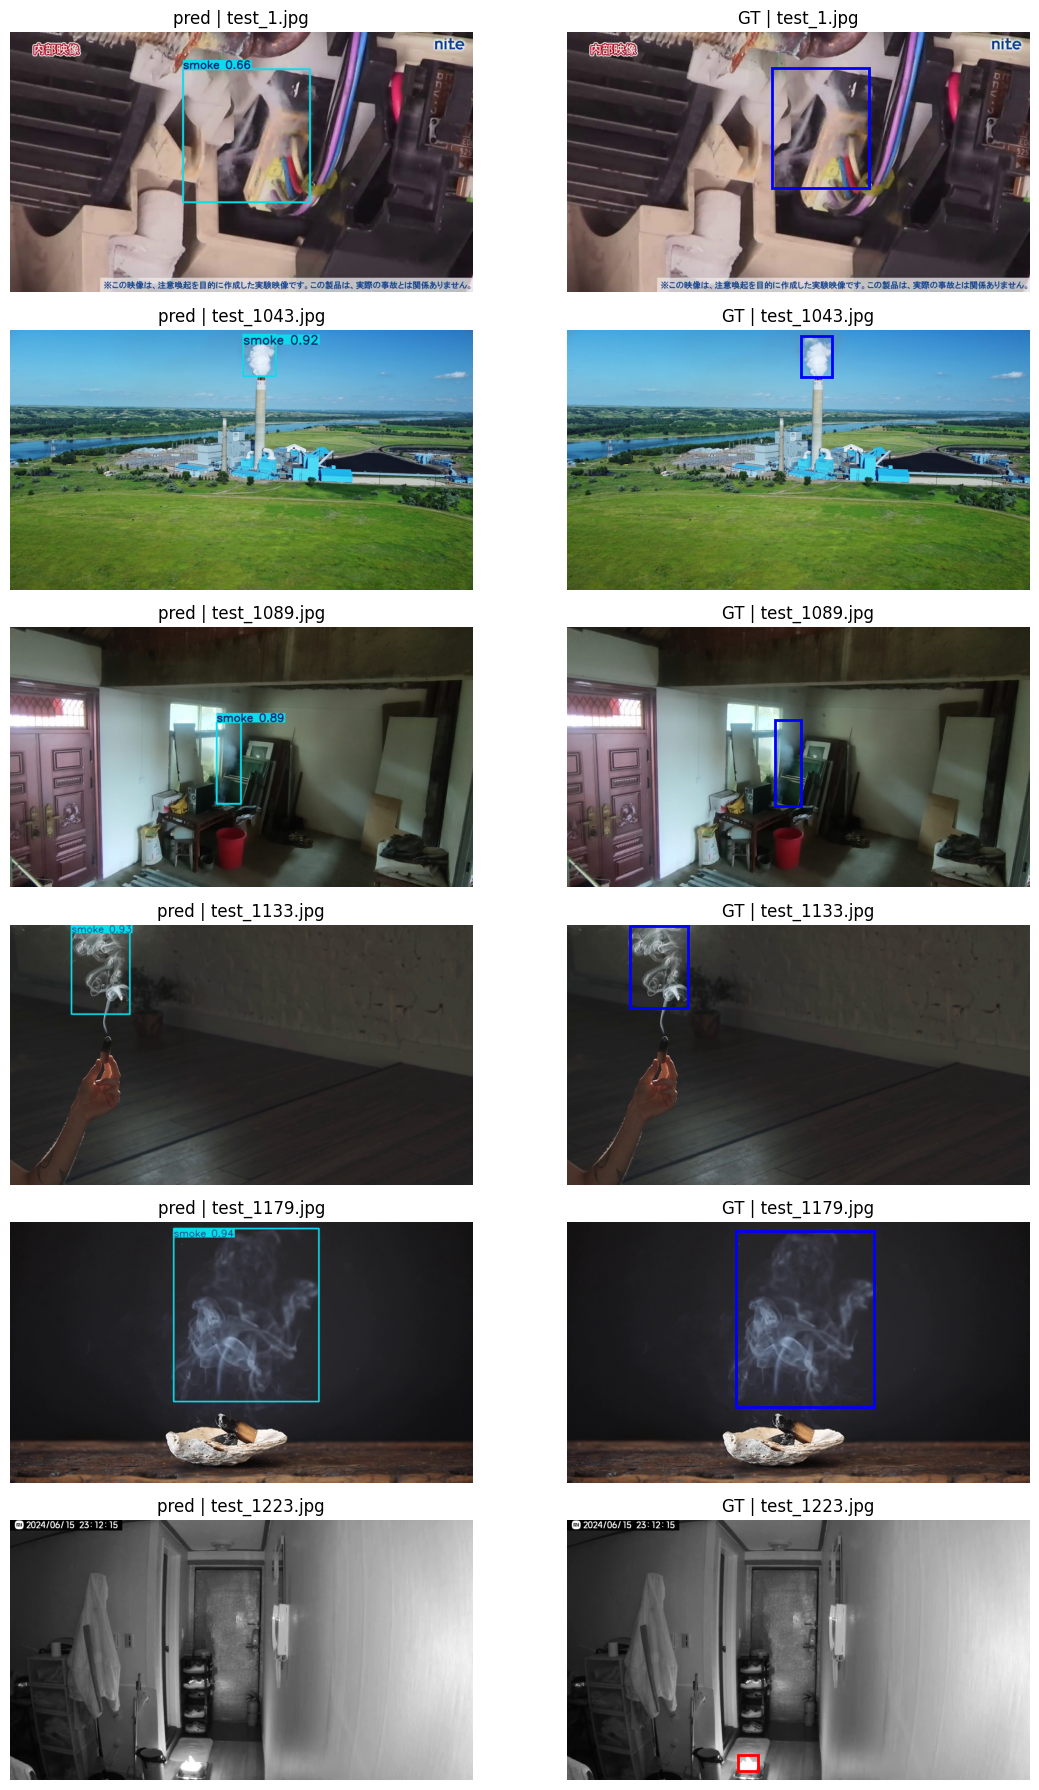

In [5]:
idxs = [0, 50, 100, 150, 200, 250]
fig, axes = plt.subplots(len(idxs), 2, figsize=(12, 3 * len(idxs)))

for row, i in enumerate(idxs):
    img_path = test_images[i]
    label_path = DATA_DIR / "test" / "labels" / f"{img_path.stem}.txt"

    result = model.predict(source=str(img_path), verbose=False)[0]
    axes[row, 0].imshow(result.plot()[:, :, ::-1])
    axes[row, 0].set_title(f"pred | {img_path.name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(Image.open(img_path))
    draw_bbox(axes[row, 1], label_path, img_path)
    axes[row, 1].set_title(f"GT | {img_path.name}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Look for misses (GT box, no pred) and false alarms (pred, no GT). Smoke is usually harder than fire.

Formal test-set metrics with default confidence.

In [6]:
test_metrics = model.val(data=str(DATA_YAML), split="test")
print_metrics("test (default conf)", test_metrics)

Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.20.0 ms, read: 468.0186.1 MB/s, size: 360.5 KB)
val: Scanning C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\labels.cache... 1300 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 13.1it/s 6.2s0.1s
                   all       1300       1586      0.906       0.83      0.897      0.574
                  fire        852        897      0.924      0.813      0.898      0.592
                 smoke        618        689      0.889      0.848      0.897      0.557
Speed: 0.6ms preprocess, 1.7ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\Arda\Desktop\Engineering\early-fire-detection\models\yolo26n\detect\val-12

=== test (default conf) ===
P=0.9064623900222123  R=0.830496

P=0.906, R=0.830, F2=0.845, mAP50=0.897. Recall is lower than on val (0.917). That is expected hyp decisions were all selected on val. Test is the honest generalization score.

Confidence sweep on val, not test, so we do not tune the threshold on the split we report. We care more about recall (F2) than precision.

In [7]:
conf_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
sweep_rows = []

In [8]:
for conf in conf_values:
    m = model.val(data=str(DATA_YAML), split="val", conf=conf, verbose=False)
    p, r = float(m.box.mp), float(m.box.mr)
    sweep_rows.append((conf, p, r, f2_score(p, r)))
    print(f"conf={conf}  P={p}  R={r}  F2={f2_score(p, r)}")

Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.30.1 ms, read: 520.5240.1 MB/s, size: 350.8 KB)
val: Scanning C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\val\labels.cache... 1300 images, 33 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 12.1it/s 6.8s0.1s
                   all       1300       1580      0.939      0.917      0.926       0.63
Speed: 0.7ms preprocess, 1.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\Arda\Desktop\Engineering\early-fire-detection\models\yolo26n\detect\val-13
conf=0.1  P=0.9387775637154094  R=0.916852674338374  F2=0.9211553397842555
Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 1922.81416

Best conf on val by F2 was 0.1, but 0.10–0.30 all gave the same F2 (0.921). Raising conf to 0.4–0.5 only hurt recall.

In [9]:
best_conf = max(sweep_rows, key=lambda row: row[3])[0]
best_conf

0.1

In [10]:
final_test_metrics = model.val(data=str(DATA_YAML), split="test", conf=best_conf)
print_metrics(f"test (conf=best{best_conf})", final_test_metrics)

Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 1632.7480.6 MB/s, size: 431.3 KB)
val: Scanning C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\labels.cache... 1300 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 13.1it/s 6.3s0.2s
                   all       1300       1586      0.906       0.83      0.862      0.553
                  fire        852        897      0.924      0.813       0.85      0.564
                 smoke        618        689      0.889      0.848      0.874      0.543
Speed: 0.6ms preprocess, 1.4ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\Arda\Desktop\Engineering\early-fire-detection\models\yolo26n\detect\val-20

=== test (conf=best0.1) ===
P=0.9064623900222123  R=0.83049

Test at conf=0.1 matches default-conf P/R/F2 (0.906 / 0.830 / 0.845). No gain from changing the threshold. We keep default confidence.

Inference speed on 50 test images (our laptop GPU).

In [11]:
import numpy as np

speeds = []
for img_path in test_images[:50]:
    result = model.predict(source=str(img_path), verbose=False)[0]
    speeds.append(result.speed["inference"])

mean_ms = np.mean(speeds)
mean_ms

np.float64(16.386117999791168)

In [12]:
fps = 1000 / mean_ms
fps

np.float64(61.027267105774804)